<a href="https://colab.research.google.com/github/babarinjayvhanlawrence-creator/Laboratory-Work-4-Activity-/blob/main/Activity4_Prediction_BABARIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. SET PATHS AND LOAD MODEL
# We don't need to unzip anymore!
dataset_path = '/content/extracted_plants/plants_Dataset'

# This loads the file you just uploaded from your laptop
model = tf.keras.models.load_model('my_plant_ai (1).h5')

# 2. CREATE THE DATASET
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(180, 180),
    batch_size=32,
    shuffle=False
)

class_names = val_ds.class_names
print(f"\n✅ Model loaded and connected to {len(class_names)} plant types!")

Found 6532 files belonging to 20 classes.
Using 1306 files for validation.

✅ Model loaded and connected to 20 plant types!


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array
import os

# 1. LOAD THE MODEL
# Siguroha nga 'my_plant_ai (1).h5' ang naa sa sidebar
model = tf.keras.models.load_model('my_plant_ai (1).h5')

# 2. GET LABELS FROM FOLDER
# Kini mokuha sa 20 ka labels gikan sa folder nga imong gi-unzip
dataset_path = '/content/plants_Dataset'
class_names = sorted(os.listdir(dataset_path))

print(f"Model loaded! Ready to recognize {len(class_names)} plants.")

Model loaded! Ready to recognize 20 plants.


Palihog pag-upload og picture sa tanom:


Saving 000001.jpg to 000001.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step

RESULT: This is Air_Plant!
CONFIDENCE: 98.49%


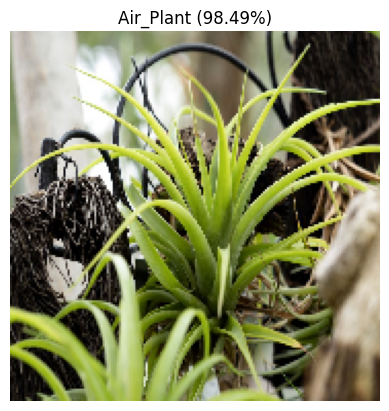

In [ ]:
# 3. UPLOAD AND PREDICT
# Siguroha nga na-run na nimo ang Cell 1 sa dili pa kini i-run
print("Palihog pag-upload og picture sa tanom:")
uploaded = files.upload()

for fn in uploaded.keys():
  img = load_img(fn, target_size=(180, 180))
  x = img_to_array(img)
  x = np.expand_dims(x, axis=0)

  # Gamiton niini ang 'model' ug 'class_names' gikan sa Cell 1
  predictions = model.predict(x)
  score = tf.nn.softmax(predictions[0])

  predicted_class = class_names[np.argmax(score)]
  confidence = 100 * np.max(score)

  print(f"\nRESULT: This is {predicted_class}!")
  print(f"CONFIDENCE: {confidence:.2f}%")

  plt.imshow(img)
  plt.title(f"{predicted_class} ({confidence:.2f}%)")
  plt.axis('off')
  plt.show()

In [ ]:
# 2. PREDICTION LOGIC (Based on your final prediction screenshots)
print("Ready for your photo!")
uploaded = files.upload()

for fn in uploaded.keys():
  img = load_img(fn, target_size=(180, 180))
  x = img_to_array(img)
  x = np.expand_dims(x, axis=0)

  predictions = model.predict(x)
  score = tf.nn.softmax(predictions[0])

  predicted_class = class_names[np.argmax(score)]
  confidence = 100 * np.max(score)

  print(f"\n>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>")
  print(f"AI ANALYSIS: This is a {predicted_class}!")
  print(f"CONFIDENCE: {confidence:.2f}%")
  print(f">>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>")

  plt.imshow(img)
  plt.title(f"{predicted_class} ({confidence:.2f}%)")
  plt.axis('off')
  plt.show()

AI is evaluating the plants... please wait...

--- ACTIVITY 4: CLASSIFICATION REPORT ---
                    precision    recall  f1-score   support

    African_Violet       0.00      0.00      0.00         0
  Black_Bat_Flower       0.00      0.00      0.00         0
    Bleeding_Heart       0.00      0.00      0.00         0
          Caladium       0.00      0.00      0.00         0
         Cockscomb       0.00      0.00      0.00         0
            Coleus       0.00      0.00      0.00         0
        Copperleaf       0.00      0.00      0.00         0
   Fiddle_Leaf_Fig       0.00      0.00      0.00         0
         Hydrangea       0.00      0.00      0.00         0
      Prayer_Plant       0.00      0.00      0.00         0
       Snake_Plant       0.79      0.93      0.85        28
     Spathiphyllum       0.99      0.96      0.97       320
        Strelitzia       0.98      0.96      0.97       273
  String_of_Pearls       0.99      0.93      0.96       355
Swiss_Chee

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


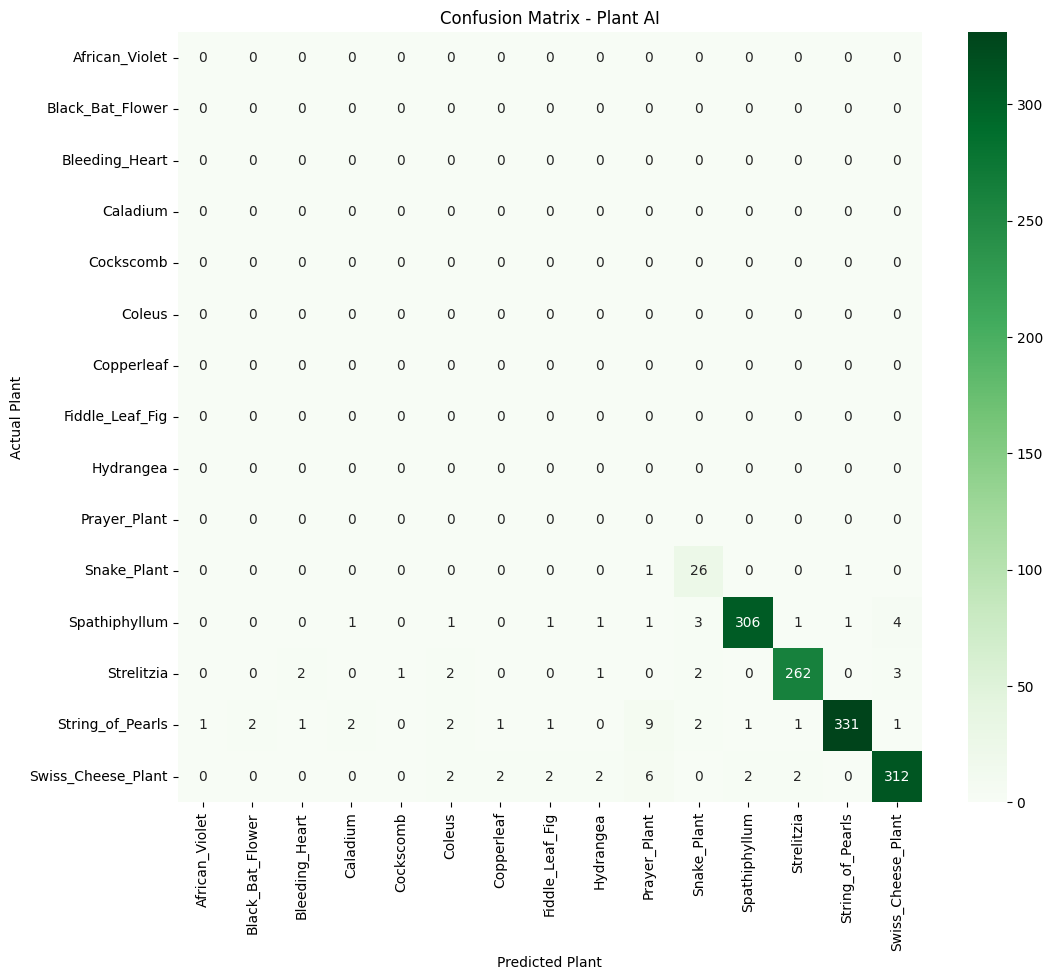

In [9]:
# 3. GENERATE THE ACTIVITY 4 RESULTS
y_true = []
y_pred = []

print("AI is evaluating the plants... please wait...")
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# AUTOMATIC CLASS FIX: This makes sure the numbers match perfectly
unique_labels = np.unique(np.concatenate([y_true, y_pred]))
# We create a simple list of names for whatever plants the AI found
final_names = [f"Plant {i}" if i >= len(class_names) else class_names[i] for i in unique_labels]

print("\n--- ACTIVITY 4: CLASSIFICATION REPORT ---")
from sklearn.metrics import classification_report, confusion_matrix
# We run the report using the labels found
print(classification_report(y_true, y_pred, labels=unique_labels, target_names=final_names))

# This draws the green grid
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=final_names, yticklabels=final_names)
plt.title("Confusion Matrix - Plant AI")
plt.ylabel('Actual Plant')
plt.xlabel('Predicted Plant')
plt.show()